<a href="https://colab.research.google.com/github/renad29amr/Juniors-2026/blob/main/Session_online_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1️⃣ Define the objective

2️⃣ Ask questions

3️⃣ Load data

4️⃣ Explore (EDA)

5️⃣ Clean

6️⃣ Analyze

7️⃣ Visualize

8️⃣ Conclude

# EDA = Exploratory Data Analysis

---> Exploring and understanding your data before doing deep analysis or modeling.

It is the stage where you investigate the dataset to discover:

1. Structure

2. Patterns

3. Problems

4. Relationships

5. Errors

### Why EDA Is Important?

* Maybe there are missing values:
    Missing data = NaN, None, empty cells.
    Now the question is:

      Do we delete the row? Or fill the missing value?
      There is NO single rule.
      You decide based on logic.

| Type              | Meaning                              | What to do             |
| ----------------- | ------------------------------------ | ---------------------- |
| Random      | Sensor glitch, user skipped randomly | Usually safe to fill   |
| Patterned    | Missing depends on another column    | Fill carefully         |
| Not random  | Missing is meaningful                | **Never blindly fill** |


* Maybe numbers are stored as text

* Maybe there are duplicates

* Maybe there are outliers



----------------
## What's outlier?

A value that is very far away from the rest of the data.

### Why Outliers Are Important?

Because they can:

* Distort the mean (average)

* Mislead analysis

* Break machine learning models

* Sometimes reveal important special cases


In [ ]:
import pandas as pd
import numpy as np

data = {
    "Name": ["Ali", "Sara", "Omar", "Mona", "Ali", "Khaled", None],
    "Age": [20, 21, "19", 22, 20, None, 23],
    "Score": [85, 90, None, 92, 85, 300, 78],
    "Gender": ["M", "F", "M", "F", "M", "M", "F"],
    "Study_Hours": [3, 4, 2, None, 3, 10, 1]
}

df = pd.DataFrame(data)

df

,Name,Age,Score,Gender,Study_Hours
0,Ali,20,85.0,M,3.0
1,Sara,21,90.0,F,4.0
2,Omar,19,NaN,M,2.0
3,Mona,22,92.0,F,NaN
4,Ali,20,85.0,M,3.0
5,Khaled,None,300.0,M,10.0
6,None,23,78.0,F,1.0


In [ ]:
print(df.head())

   Name Age  Score Gender  Study_Hours
0   Ali  20   85.0      M          3.0
1  Sara  21   90.0      F          4.0
2  Omar  19    NaN      M          2.0
3  Mona  22   92.0      F          NaN
4   Ali  20   85.0      M          3.0


In [ ]:
print(df.tail())

     Name   Age  Score Gender  Study_Hours
2    Omar    19    NaN      M          2.0
3    Mona    22   92.0      F          NaN
4     Ali    20   85.0      M          3.0
5  Khaled  None  300.0      M         10.0
6    None    23   78.0      F          1.0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         6 non-null      object 
 1   Age          6 non-null      object 
 2   Score        6 non-null      float64
 3   Gender       7 non-null      object 
 4   Study_Hours  6 non-null      float64
dtypes: float64(2), object(3)
memory usage: 412.0+ bytes
None


In [ ]:
print(df.describe())

            Score  Study_Hours
count    6.000000     6.000000
mean   121.666667     3.833333
std     87.500095     3.188521
min     78.000000     1.000000
25%     85.000000     2.250000
50%     87.500000     3.000000
75%     91.500000     3.750000
max    300.000000    10.000000


In [ ]:
print(df.isnull().sum())

Name           1
Age            1
Score          1
Gender         0
Study_Hours    1
dtype: int64


In [ ]:
print(df.duplicated().sum())

1


In [ ]:
df["Score"].fillna(df["Score"].mean(), inplace=True)


/tmp/ipython-input-1316460612.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Score"].fillna(df["Score"].mean(), inplace=True)


In [ ]:
df.dropna(inplace=True)


In [ ]:
df["Age"] = df["Age"].astype(int)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 4
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         4 non-null      object 
 1   Age          4 non-null      int64  
 2   Score        4 non-null      float64
 3   Gender       4 non-null      object 
 4   Study_Hours  4 non-null      float64
dtypes: float64(2), int64(1), object(2)
memory usage: 192.0+ bytes


In [ ]:
df.describe()

,Age,Score,Study_Hours
count,4.000000,4.000000,4.000000
mean,20.000000,95.416667,3.000000
std,0.816497,17.658017,0.816497
min,19.000000,85.000000,2.000000
25%,19.750000,85.000000,2.750000
50%,20.000000,87.500000,3.000000
75%,20.250000,97.916667,3.250000
max,21.000000,121.666667,4.000000


In [ ]:
df["Score"].mean() # ---> all ages


np.float64(95.41666666666667)

In [ ]:
df["Score"].max()


121.66666666666667

In [ ]:
df.groupby("Age")["Score"].mean() # calculate score for each age


,Score
Age,
19,121.666667
20,85.000000
21,90.000000


In [ ]:
# #Use when:

# Comparing categories

# Example: Student scores
sns.barplot(x="Name", y="Score", data=df)
plt.title("Scores of Students")
plt.show()


In [ ]:
# Use when:

# Showing change over time
plt.plot(df["Name"], df["Score"])
plt.title("Score Trend")
plt.show()


#pandas

In [ ]:
import pandas
# Create a DataFrame
data = {
    "Name": ["Harry", "Ron", "Hermione"],
    "House": ["Gryffindor", "Gryffindor", "Gryffindor"],
    "Marks": [85, 78, 95]
}

df = pandas.DataFrame(data)

# Show the DataFrame
print(df)

# Access a column
print(df["Marks"])

# # Calculate average marks
print(df["Marks"].mean())

       Name       House  Marks
0     Harry  Gryffindor     85
1       Ron  Gryffindor     78
2  Hermione  Gryffindor     95
0    85
1    78
2    95
Name: Marks, dtype: int64
86.0


In [ ]:
import pandas as pd

# Big dictionary of data
data = {
    "Name": ["Harry", "Ron", "Hermione", "Draco", "Neville", "Luna", "Cho", None],
    "House": ["Gryffindor", "Gryffindor", "Gryffindor", "Slytherin", "Gryffindor", "Ravenclaw", "Ravenclaw", "Hufflepuff"],
    "Marks": [85, 78, 95, 67, None, 88, 72, 60],
    "Age": [17, 17, 17, 17, 17, None, 17, 16]
}

df = pd.DataFrame(data)
print(df)
# Calculate average marks
print(df["Marks"].mean())

       Name       House  Marks   Age
0     Harry  Gryffindor   85.0  17.0
1       Ron  Gryffindor   78.0  17.0
2  Hermione  Gryffindor   95.0  17.0
3     Draco   Slytherin   67.0  17.0
4   Neville  Gryffindor    NaN  17.0
5      Luna   Ravenclaw   88.0   NaN
6       Cho   Ravenclaw   72.0  17.0
7      None  Hufflepuff   60.0  16.0
77.85714285714286


In [ ]:
df.loc[0, "Name"]   # Harry
#df.loc[:, "Marks"]  # All marks

'Harry'

In [ ]:
df.iloc[0, 1]   # First row, second column → Gryffindor
df.iloc[:, 2]   # All marks

,Marks
0,85.0
1,78.0
2,95.0
3,67.0
4,NaN
5,88.0
6,72.0
7,60.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
df_clean = df.dropna()

In [ ]:
df_filled = df.fillna(0)   # Replace missing with 0

In [ ]:
df.groupby("House")["Marks"].mean()

In [ ]:
extra = pd.DataFrame({
    "Name": ["Harry", "Hermione", "Draco"],
    "Club": ["Quidditch", "Debate", "Dueling"]
})

merged = pd.merge(df, extra, on="Name")

In [ ]:
df2 = pd.DataFrame({
    "Name": ["Ginny", "Fred"],
    "House": ["Gryffindor", "Gryffindor"],
    "Marks": [82, 75],
    "Age": [16, 17]
})

combined = pd.concat([df, df2])

In [ ]:
df["Marks"].mean()    # Average marks
df["Marks"].sum()     # Total marks
df["Marks"].min()     # Lowest mark
df["Marks"].max()     # Highest mark
df["Marks"].count()   # Number of non-empty marks
df["Marks"].median()  # Middle mark
df["Marks"].std()     # Spread of marks

Data analysis =

- Ask a question
- Collect data
- Clean it
- Analyze it
- Explain what it means

# Why Use NumPy?

In Python we have lists that serve the purpose of arrays, but they are slow to process.

NumPy aims to provide an array object that is up to 50x faster than traditional Python lists.

The array object in NumPy is called `ndarray`, it provides a lot of supporting functions that make working with `ndarray` very easy.

Arrays are very frequently used in data science, where speed and resources are very important.

NumPy in data analysis flow

use NumPy to:

* Handle numerical data

* Prepare data for Pandas

* Do fast calculations

* Support ML later

Pandas is built on NumPy

In [ ]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5])

print(arr)
print(type(arr))

In [ ]:
arr = np.array([1, 2, 3, 4])

print(arr + 2)    # add
print(arr * 3)    # multiply

In [ ]:
print(np.zeros(5))        # [0. 0. 0. 0. 0.]
print(np.ones(3))         # [1. 1. 1.]
print(np.arange(1, 6))    # [1 2 3 4 5]
print(np.linspace(0, 1, 5))  # evenly spaced

In [ ]:
arr = np.array([5, 10, 15, 20])

print(arr.mean())   # average
print(arr.max())    # max
print(arr.min())    # min
print(arr.sum())    # sum


In [ ]:
# Indexing ---> Access Array Elements
arr = np.array([1, 2, 3, 4])

print(arr[0])

In [ ]:
#Conditions & filtering (VERY important)
arr = np.array([10, 15, 20, 25, 30])

print(arr[arr > 20])


In [ ]:
#2D arrays (tables)
data = np.array([
    [80, 90, 70],
    [85, 88, 92]
])

print(data)


In [ ]:
# Access
data[0][1]   # 90

In [ ]:
# Check Number of Dimensions
a = np.array(42)
b = np.array([1, 2, 3, 4, 5])
c = np.array([[1, 2, 3], [4, 5, 6]])
d = np.array([[[1, 2, 3], [4, 5, 6]], [[1, 2, 3], [4, 5, 6]]])

print(a.ndim)
print(b.ndim)
print(c.ndim)
print(d.ndim)

In [ ]:
arr = np.array([[1, 2, 3, 4], [5, 6, 7, 8]])

print(arr.shape)

In [ ]:
arr = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

newarr = arr.reshape(4, 3)

print(newarr)

In [ ]:
# Slicing arrays ---> [start:end:step]
arr = np.array([1, 2, 3, 4, 5, 6, 7])

print(arr[1:5])

In [ ]:
# Slicing 2-D Arrays
arr = np.array([[1, 2, 3, 4, 5], [6, 7, 8, 9, 10]])

print(arr[1, 1:4])

In [ ]:
# array[row_range, column]
arr = np.array([[1, 2, 3, 4, 5], [6, 7, 8, 9, 10]])

print(arr[0:2, 2])

In [ ]:
# array[row_start:row_end, col_start:col_end]
arr = np.array([[1, 2, 3, 4, 5], [6, 7, 8, 9, 10]])

print(arr[0:2, 1:4])

In [ ]:
# Notice ints became floats automatically.
# NumPy did this to make calculations consistent and fast.

arr = np.array([1, 2, 3.5, 4])
print(arr)
print(arr.dtype)


In [ ]:
# Numbers are converted to strings.
# NumPy always tries to make all elements the same type.

arr = np.array([1, "hello", 3])
print(arr)
print(arr.dtype)
# Why it happened

# NumPy upcasts all elements to the most general type that can hold everything.

# Original list: [1, "hello", 3] → mix of int and str

# NumPy converts all to strings → "1", "hello", "3"

# The longest string is "hello" → 5 characters → <U5

In [ ]:
arr = np.array([1, 2, 3, 4, 5])
x = arr
arr[0] = 42

print(arr)
print(x)

In [ ]:
arr = np.array([1, 2, 3, 4, 5])
x = arr.copy()
arr[0] = 42

print(arr)
print(x)

In [ ]:
arr = np.array([1, 2, 3])

for x in arr:
  print(x)

In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6]])

for x in arr:
  print(x)

In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6]])

for x in arr:
  for y in x:
    print(y)

In [ ]:
arr = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])

for x in arr:
  for y in x:
    for z in y:
      print(z)

In [ ]:
arr = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

for x in np.nditer(arr):
  print(x)

In [ ]:
# Joining NumPy Arrays
arr1 = np.array([1, 2, 3])

arr2 = np.array([4, 5, 6])

arr = np.concatenate((arr1, arr2))

print(arr)

In [ ]:
# Searching in Array
arr = np.array([1, 2, 3, 4, 5, 4, 4])

x = np.where(arr == 4)

print(x)

In [ ]:
arr = np.array([1, 2, 3, 4, 5, 6, 7, 8])

x = np.where(arr%2 == 0)

print(x)

In [ ]:
arr = np.array([3, 2, 0, 1])

print(np.sort(arr))

In [ ]:
# filtering in arr
arr = np.array([41, 42, 43, 44])

filter_arr = arr > 42

newarr = arr[filter_arr]

print(filter_arr)
print(newarr)

* Some analysts use thresholds like 50%, 60%, or even 70% missing values as a starting point for considering column deletion.

* Advantages and Disadvantages
Advantage: Simplicity. Removing the column entirely eliminates the missing data problem for that feature without needing complex imputation. It can also speed up subsequent processing by reducing the dataset's dimensionality.
Advantage: Avoids introducing potentially biased data through imputation, especially when the missingness is very high.
Disadvantage: Information Loss. This is the most significant drawback. Even if a column has many missing values, the few values that are present might hold valuable information. Deleting the column means losing that information entirely.
Disadvantage: Potential Impact on Other Features. Sometimes, the pattern of missingness itself can be informative, or the feature might be important when considered alongside others, even if sparse.

Before dropping a column:

* Assess the Percentage: Quantify how much data is actually missing.

* Evaluate Feature Importance: Consider how relevant this feature might be to your analysis goals. Is it theoretically important? Could it be useful even if sparse?

* Consider Alternatives: Think about whether imputation techniques (discussed next) might be feasible and less damaging, even if the missing percentage is somewhat high.

## What is Seaborn?

**Seaborn** is a Python library used to **visualize data**.

* Built on top of **Matplotlib**
* Works perfectly with **Pandas DataFrames**
* Creates **clean, beautiful statistical charts** with very little code


> **Pandas** → organizes data

> **Seaborn** → shows the story in the data 📊



## Why use Seaborn?

* Less code than Matplotlib
* Better default colors & styles
* Built-in statistical plots
* Easy comparison between categories


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Name": ["Ali", "Sara", "Omar", "Mona", "Youssef", "Nour", "Ahmed", "Laila"],
    "Score": [85, 92, 78, 88, 95, 70, 60, 82],
    "Gender": ["Male", "Female", "Male", "Female", "Male", "Female", "Male", "Female"],
    "Class": ["A", "A", "B", "B", "A", "B", "A", "B"],
    "Hours_Studied": [5, 7, 4, 6, 8, 3, 2, 5],
    "Passed": ["Yes", "Yes", "No", "Yes", "Yes", "No", "No", "Yes"]
}

df = pd.DataFrame(data)
print(df)


      Name  Score  Gender Class  Hours_Studied Passed
0      Ali     85    Male     A              5    Yes
1     Sara     92  Female     A              7    Yes
2     Omar     78    Male     B              4     No
3     Mona     88  Female     B              6    Yes
4  Youssef     95    Male     A              8    Yes
5     Nour     70  Female     B              3     No
6    Ahmed     60    Male     A              2     No
7    Laila     82  Female     B              5    Yes


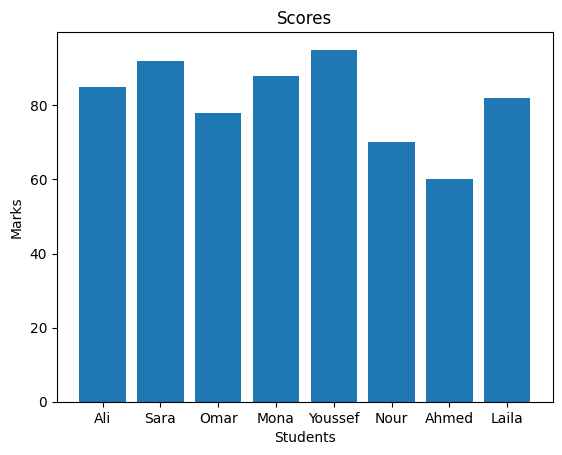

In [ ]:
# Matplotlib:
plt.bar(df["Name"], df["Score"])
plt.title("Scores")
plt.xlabel("Students")
plt.ylabel("Marks")
plt.show()


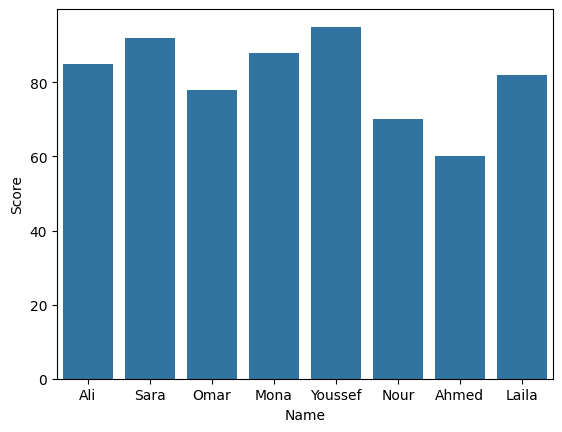

In [ ]:
# seaborn
sns.barplot(x="Name", y="Score", data=df)
plt.show()

| Task            | Matplotlib      | Seaborn            |
| --------------- | --------------- | ------------------ |
| Box plot        | `plt.boxplot()` | `sns.boxplot()`    |
| Violin plot     | ❌               | `sns.violinplot()` |
| Count plot      | ❌               | `sns.countplot()`  |
| Regression plot | ❌               | `sns.regplot()`    |
| Heatmap         | ❌               | `sns.heatmap()`    |


Titles, labels, control ---> Matplotlib

| Task        | Function        |
| ----------- | --------------- |
| Title       | `plt.title()`   |
| X label     | `plt.xlabel()`  |
| Y label     | `plt.ylabel()`  |
| Figure size | `plt.figure()`  |
| Save plot   | `plt.savefig()` |
| Show plot   | `plt.show()`    |


Styling and themes:
| Feature        | Matplotlib | Seaborn       |
| -------------- | ---------- | ------------- |
| Default style  | Basic      | Beautiful     |
| Themes         | Limited    | `set_style()` |
| Color palettes | Manual     | Built-in      |


Styling & Themes

When we talk about **styling**, we mean:

* Colors
* Background
* Grid lines
* Overall “look” of the chart

---

## 1️⃣ Default style

### 🔹 Matplotlib (default = basic)

If you plot **without doing anything**:

```python
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()
```

You get:

* White background
* Thin lines
* No grid
* Very plain

👉 Matplotlib assumes **you will customize everything yourself**.

---

### 🔹 Seaborn (default = beautiful)

```python
sns.lineplot(x=[1,2,3], y=[4,5,6])
plt.show()
```

You get:

* Soft colors
* Clean grid
* Better spacing
* Readable fonts

👉 Seaborn is designed for **data analysis & presentation**, so it styles things automatically.

---

## 2️⃣ Themes (styles)

### What is a theme?

A **theme** controls:

* Background color
* Grid visibility
* Axis style

---

### 🔹 Seaborn themes (easy & built-in)

```python
sns.set_style("darkgrid")
```

Common styles:

* `"white"`
* `"dark"`
* `"whitegrid"`
* `"darkgrid"`
* `"ticks"`

Example:

```python
sns.set_style("whitegrid")
sns.barplot(x="Name", y="Score", data=df)
plt.show()
```

✅ One line → full professional look

---

###Matplotlib themes (limited & manual)

Matplotlib **can** style plots, but:

* More code
* Less intuitive
* Not data-focused

You often need:

```python
plt.grid(True)
plt.style.use("ggplot")
```

Still less polished than Seaborn by default.

---

## 3️⃣ Color palettes

###Matplotlib (manual colors)

You must specify colors yourself:

```python
plt.bar(df["Name"], df["Score"], color="green")
```

If you want multiple colors → more work.

---

###Seaborn (automatic palettes)

Seaborn has **built-in color palettes**:

```python
sns.set_palette("pastel")
sns.barplot(x="Name", y="Score", data=df)
```

Popular palettes:

* `"deep"`
* `"pastel"`
* `"muted"`
* `"bright"`
* `"coolwarm"`

--->Seaborn automatically assigns colors (especially useful with `hue`).

---

## 4️⃣ Why this matters in real life

Imagine this question:

> “Which class performs better by gender?”

### With Matplotlib:

* Manual grouping
* Manual colors
* Manual legends

### With Seaborn:

```python
sns.barplot(x="Class", y="Score", hue="Gender", data=df)
```

✔ Styled
✔ Colored
✔ Grouped
✔ Ready to present


### 1️⃣ Bar Plot – comparison

Used for:

* Comparing categories
* Shows **average value** by default

##**Without plt.show():**

* **In scripts → nothing appears**

* **In notebooks → may or may not auto-display**

In [ ]:
sns.barplot(x="Name", y="Score", data=df)
plt.show()

### 2️⃣ Line Plot – trends

Used for:

* Time trends
* Continuous data


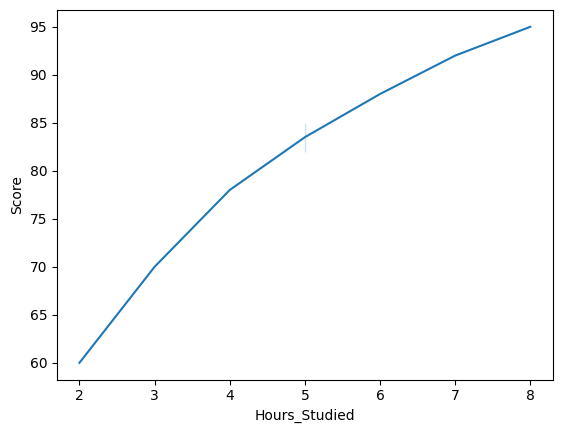

In [ ]:
sns.lineplot(x="Hours_Studied", y="Score", data=df) # seaborn
plt.show() # matplolib


### 3️⃣ Histogram – distribution

Used for:

* Frequency
* Understanding spread


In [ ]:
sns.histplot(df["Score"], bins=5)
plt.show()

### 4️⃣ Box Plot – outliers & spread

Used for:

* Median
* Quartiles
* Outliers



In [ ]:
sns.boxplot(y="Score", data=df)
plt.show()

### 5️⃣ Scatter Plot – relationship

Used for:

* Relationship between two numbers

In [ ]:
sns.scatterplot(x="Hours_Studied", y="Score", data=df)
plt.show()


### 6️⃣ Count Plot – category counts

Used for:

* Counting YES / NO
* Gender, status, types


In [ ]:
sns.countplot(x="Passed", data=df)
plt.show()

## `hue` (VIP)

*   List item
*   List item



Adds a second category:

This lets you compare **groups inside groups**.

In [ ]:
# What happens here?

# x="Class" → Classes A and B

# y="Score" → Average score

# hue="Gender" → Split each class by Male vs Female

# Result:

# Each class has two bars

# Different colors = different genders

# You can compare Male vs Female inside each class

sns.barplot(x="Class", y="Score", hue="Gender", data=df)
plt.show()

# Matplotlib
# ❌ Very long & manual code

## Heatmap (correlation)

Used for:

* Finding relationships
* Feature selection

In [ ]:
corr = df[["Score", "Hours_Studied"]].corr()
sns.heatmap(corr, annot=True)
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# load the tips dataset present by default in seaborn
tips = sns.load_dataset('tips')
# style must be one of white, dark, whitegrid, darkgrid, ticks
sns.set_style('darkgrid')
sns.countplot(x ='sex', data = tips)
plt.show()

In [ ]:
plt.bar(df["Name"], df["Score"])


In [ ]:
sns.barplot(x="Name", y="Score", data=df)
